In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# prev. visualization of opt. results

In [2]:
#inspecting ternary as in prj file str

def protocol_replace(protocol_str):
    clean_str= protocol_str.replace("&lt;", "<")
    tokens= clean_str.split()

    times=[]
    rates=[]

    for i, token in enumerate(tokens):
        if token=="<":
            time_val=tokens[i+1].rstrip(".")
            times.append(float(time_val))
        elif token=="?":
            rates.append(float(tokens[i+1]))
    final_rate=float(tokens[-1])

    plot_times=times
    plot_rates=rates#+[final_rate]

    return plot_times,plot_rates

In [3]:
cwd=Path.cwd()
raw_paths= list((cwd).glob("*.npy"))

file_paths= sorted(
    raw_paths,
    key= lambda p: int(p.stem.split("_")[1])
)

iter_list=[np.load(file,allow_pickle=True).item() for file in file_paths]

In [4]:
field_data_path=cwd.parent/"STIMTEC_example/BH10_20180718_40.6_SR_v2.csv"
field_data=pd.read_csv(field_data_path,header=0)
#protocols
#v1

pro_v1=pd.read_csv(cwd.parent/"STIMTEC_example/protocol_SR.csv",header=0)
pro_v2=pd.read_csv(cwd.parent/"STIMTEC_example/protocol_SR_v2.csv",header=0)

In [92]:
#flow protocols
#v1
qv1="t &lt; 1794.21 ? 2.99E-07 : t &lt; 1909.81 ? 5.57E-05 : t &lt; 2079.81 ? 1.14E-04 : t &lt; 2160.01 ? 2.05E-04 : t &lt; 2330.81 ? 4.05E-04 : t &lt; 2430.41 ? 6.06E-04 : t &lt; 2517.81 ? 7.97E-04 : t &lt; 2669.81 ? 0 : 0"
#v2
qv2= "t &lt; 1788.809	?	2.99E-07 : t &lt; 1904.409	?	5.31E-05 : t &lt; 2074.009	?	1.14E-04 : t &lt; 2154.409	?	2.04E-04 : t &lt; 2325.409 ?	4.01E-04 : t &lt; 2424.809	?	6.02E-04 : t &lt; 2511.409	?	7.90E-04 : t &lt; 2669.81 ? 0 : 0"

qarra1=protocol_replace(qv1)
qarra2=protocol_replace(qv2)

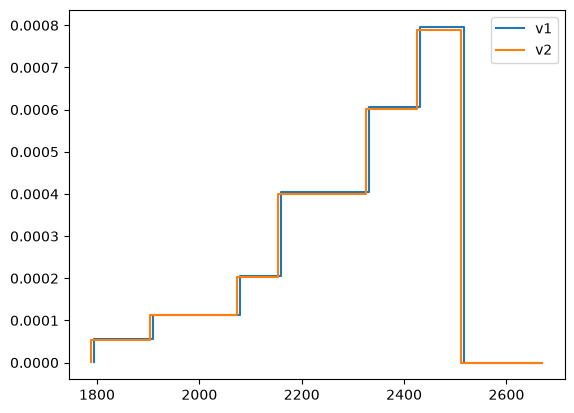

In [95]:
plt.step(qarra1[0],qarra1[1],label="v1")
plt.step(qarra2[0],qarra2[1],label="v2")
plt.legend()
plt.pause(1)

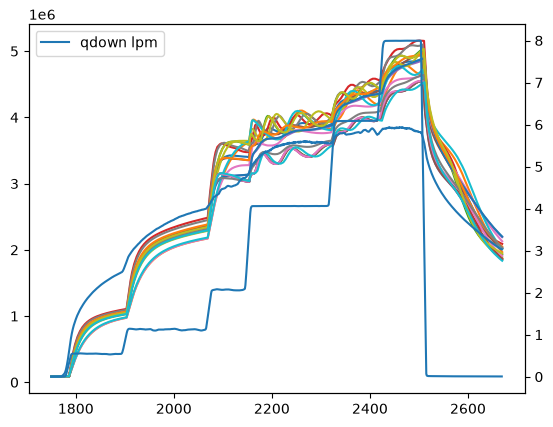

In [5]:
fig, ax= plt.subplots(sharex=True)
ax1=ax.twinx()
for budle in iter_list:
    ax.plot(budle["timevalues"],budle["values"])
ax.plot(field_data["Zeit [s]"], field_data["Pint_downhole [MPa]_s"]*1e6,label="Field pressure Pa" )
ax1.plot(field_data["Zeit [s]"], field_data["Q_downhole [lpm]_s"],label="qdown lpm",  )
#ax1.step(qarra2[0],qarra2[1],label="v2") #in m3/s

# for i in range(len(pro_v1)):
#     plt.axvline(pro_v1.loc[i,'T_s [s]'],ls="--",color="k")

# for j in range(len(pro_v2)):    
#     plt.axvline(pro_v2.loc[j,'T_s'],ls="--",color="tab:blue",label="q prot")
# ax.set_ylim(0,6e6)

plt.legend()
plt.pause(1)

In [14]:
for value in iter_list:
    print(value['metadata'])

{'pjack': 3605000.0, 'wr': 197000.0, 'iteration': 1, 'cost': np.float64(1682082.024568462)}
{'pjack': 3605000.0, 'wr': 202508.7787265592, 'iteration': 2, 'cost': np.float64(1733270.999218295)}
{'pjack': 3373586.6031191307, 'wr': 203829.97575450424, 'iteration': 3, 'cost': np.float64(1936518.7416795308)}
{'pjack': 3605000.0, 'wr': 305965.68403852335, 'iteration': 4, 'cost': np.float64(2587121.5833921377)}
{'pjack': 3605000.0, 'wr': 294497.22150200594, 'iteration': 5, 'cost': np.float64(2537368.200502974)}
{'pjack': 3534685.1371000507, 'wr': 449505.80778168794, 'iteration': 6, 'cost': np.float64(2634084.9480771357)}
{'pjack': 3590413.3051671935, 'wr': 354868.3557593854, 'iteration': 7, 'cost': np.float64(2633172.461422878)}
{'pjack': 3115208.655875759, 'wr': 248856.74891714077, 'iteration': 8, 'cost': np.float64(2528259.777063974)}
{'pjack': 3120654.3545787414, 'wr': 476518.36845768255, 'iteration': 9, 'cost': np.float64(2634087.1532981154)}
{'pjack': 3605000.0, 'wr': 422377.33472691284,